<a href="https://colab.research.google.com/github/cacacutie/AI-Naive-Bayes-Diabetes/blob/main/naive_bayes_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Naive Bayes - Diabetes Dataset
**Tugas Lecture 4 – Naïve Bayes**

Notebook ini menerapkan Naive Bayes pada dataset diabetes, mulai dari load data, training, evaluasi, sampai perhitungan manual menggunakan rumus dari slide kuliah.

---

## LANGKAH 1: Mount Google Drive
Upload file `diabetes.csv` ke Google Drive kamu dulu (boleh di folder mana saja), lalu jalankan cell ini.

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive berhasil di-mount!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount!


## LANGKAH 2: Load Dataset
Ganti path di bawah sesuai lokasi file CSV kamu di Drive. Contoh: `/content/drive/MyDrive/diabetes.csv`

In [6]:
import pandas as pd
import numpy as np

# ⬇️ Ganti path ini sesuai lokasi file kamu di Google Drive
PATH = '/content/drive/MyDrive/AI/diabetes.csv'

df = pd.read_csv(PATH)
print('✅ Dataset berhasil dimuat!')
print(f'Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

✅ Dataset berhasil dimuat!
Jumlah data: 768 baris, 9 kolom


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## LANGKAH 3: Eksplorasi Data

In [7]:
print('=== Informasi Dataset ===')
print(df.info())

print('\n=== Distribusi Kelas (Outcome) ===')
print(df['Outcome'].value_counts())
print(f"\nKelas 0 (Tidak Diabetes): {(df['Outcome']==0).sum()} data")
print(f"Kelas 1 (Diabetes)       : {(df['Outcome']==1).sum()} data")

print('\n=== Statistik Deskriptif ===')
df.describe().round(4)

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Distribusi Kelas (Outcome) ===
Outcome
0    500
1    268
Name: count, dtype: int64

Kelas 0 (Tidak Diabetes): 500 data
Kelas 1 (Diabetes)       : 268 data

=== Statistik Deskriptif ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.0000,768.000
mean,3.8451,120.8945,69.1055,20.5365,79.7995,31.9926,0.4719,33.2409,0.349
std,3.3696,31.9726,19.3558,15.9522,115.2440,7.8842,0.3313,11.7602,0.477
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0780,21.0000,0.000
25%,1.0000,99.0000,62.0000,0.0000,0.0000,27.3000,0.2438,24.0000,0.000
50%,3.0000,117.0000,72.0000,23.0000,30.5000,32.0000,0.3725,29.0000,0.000
75%,6.0000,140.2500,80.0000,32.0000,127.2500,36.6000,0.6262,41.0000,1.000
max,17.0000,199.0000,122.0000,99.0000,846.0000,67.1000,2.4200,81.0000,1.000


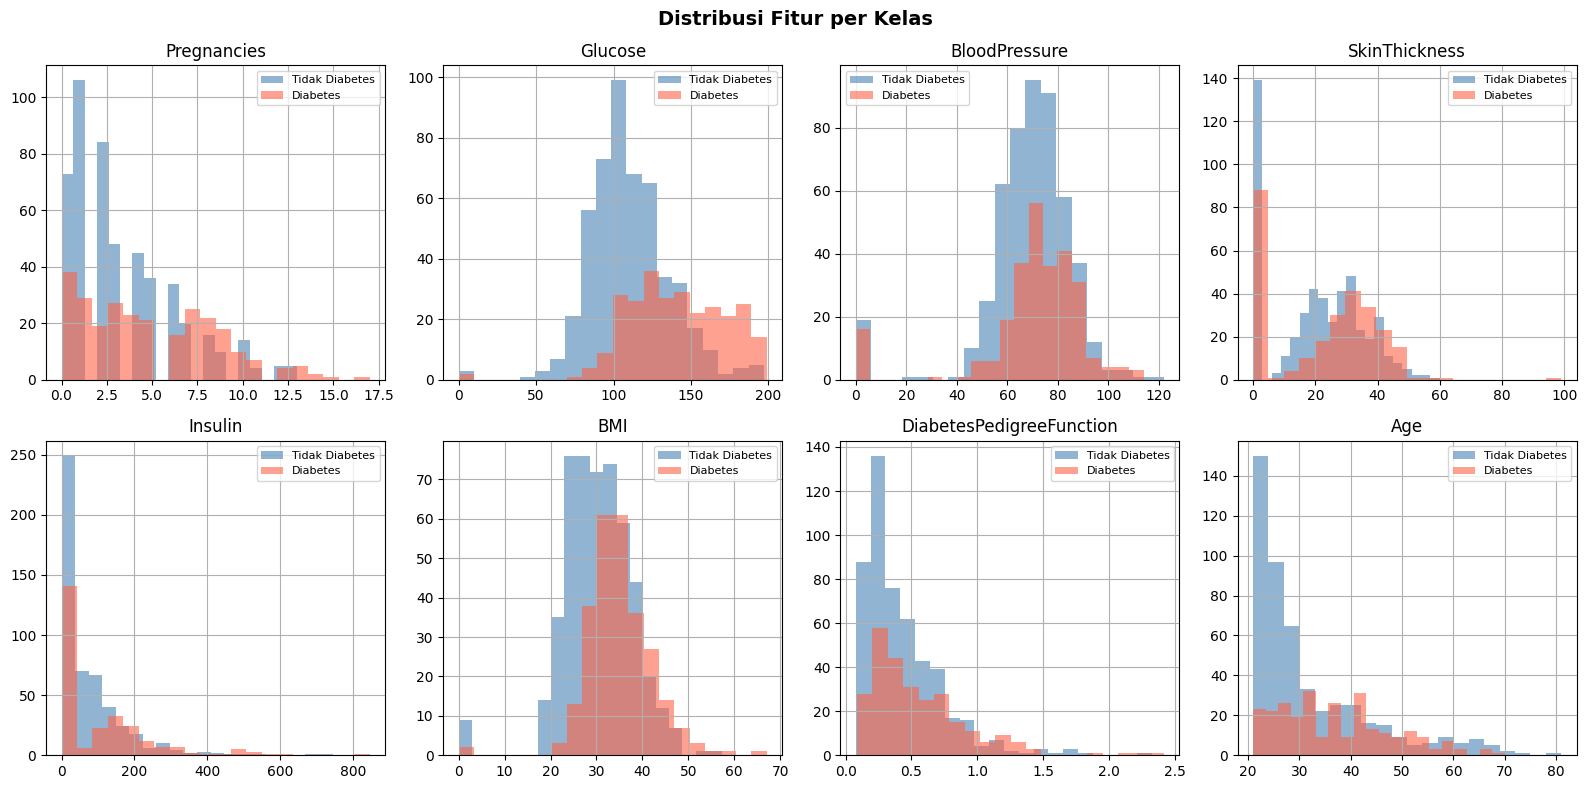

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = df.columns[:-1]

for i, col in enumerate(features):
    ax = axes[i//4][i%4]
    df[df['Outcome']==0][col].hist(ax=ax, alpha=0.6, label='Tidak Diabetes', bins=20, color='steelblue')
    df[df['Outcome']==1][col].hist(ax=ax, alpha=0.6, label='Diabetes', bins=20, color='tomato')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## LANGKAH 4: Persiapan Data

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split 80% train, 20% test, random_state=42 agar hasil reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Data training : {X_train.shape[0]} baris')
print(f'Data testing  : {X_test.shape[0]} baris')

Data training : 614 baris
Data testing  : 154 baris


## LANGKAH 5: Training Model Naive Bayes
Kita pakai **Gaussian Naive Bayes** karena semua fitur bernilai kontinu (bukan teks). Sesuai dengan slide kuliah yang menghitung likelihood P(X|Y) menggunakan distribusi Gaussian.

In [10]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

print('✅ Model selesai di-training!')
print(f'Jumlah kelas: {model.classes_}')

✅ Model selesai di-training!
Jumlah kelas: [0 1]


## LANGKAH 6: Evaluasi Model

=== HASIL EVALUASI MODEL ===
Accuracy : 0.7662 (76.62%)

Classification Report:
                precision    recall  f1-score   support

Tidak Diabetes       0.83      0.80      0.81        99
      Diabetes       0.66      0.71      0.68        55

      accuracy                           0.77       154
     macro avg       0.75      0.75      0.75       154
  weighted avg       0.77      0.77      0.77       154



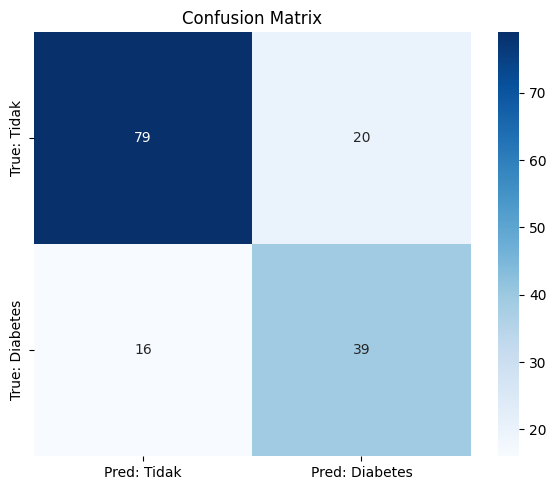

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'=== HASIL EVALUASI MODEL ===')
print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes','Diabetes']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Tidak','Pred: Diabetes'],
            yticklabels=['True: Tidak','True: Diabetes'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## LANGKAH 7: Lihat Parameter Model (Prior & Likelihood)
Ini sesuai dengan slide kuliah – kita lihat nilai **prior P(Y)** dan **likelihood parameters (mean & variance)**.

In [12]:
print('=== PRIOR P(Y) ===')
for i, c in enumerate(model.classes_):
    label = 'Tidak Diabetes' if c==0 else 'Diabetes'
    print(f'P(Y={c} | {label}) = {model.class_prior_[i]:.4f}')

print('\n=== LIKELIHOOD PARAMETERS: Mean per Kelas ===')
mean_df = pd.DataFrame(
    model.theta_,
    columns=X.columns,
    index=['Tidak Diabetes (Y=0)', 'Diabetes (Y=1)']
)
print(mean_df.round(4))

print('\n=== LIKELIHOOD PARAMETERS: Variance per Kelas ===')
var_df = pd.DataFrame(
    model.var_,
    columns=X.columns,
    index=['Tidak Diabetes (Y=0)', 'Diabetes (Y=1)']
)
print(var_df.round(4))

=== PRIOR P(Y) ===
P(Y=0 | Tidak Diabetes) = 0.6531
P(Y=1 | Diabetes) = 0.3469

=== LIKELIHOOD PARAMETERS: Mean per Kelas ===
                      Pregnancies   Glucose  BloodPressure  SkinThickness  \
Tidak Diabetes (Y=0)       3.2419  110.2145        68.3092        19.7481   
Diabetes (Y=1)             4.6854  140.8873        71.4977        21.6244   

                      Insulin      BMI  DiabetesPedigreeFunction      Age  
Tidak Diabetes (Y=0)  72.2544  30.2566                    0.4313  30.5561  
Diabetes (Y=1)        98.7277  35.2343                    0.5405  37.3333  

=== LIKELIHOOD PARAMETERS: Variance per Kelas ===
                      Pregnancies    Glucose  BloodPressure  SkinThickness  \
Tidak Diabetes (Y=0)       9.1360   676.6373       311.2660       212.0887   
Diabetes (Y=1)            13.0325  1065.1610       393.6772       283.9622   

                         Insulin      BMI  DiabetesPedigreeFunction       Age  
Tidak Diabetes (Y=0)  10207.7009  56.6926       

## LANGKAH 8: Perhitungan Manual Menggunakan Rumus Naive Bayes

Berdasarkan slide kuliah, rumus Naive Bayes (dengan log untuk menghindari floating-point underflow):

$$\hat{y} = \arg\max_y \left[ \ln P(Y=y) + \sum_{i=1}^{n} \ln P(W=w_i | Y=y) \right]$$

Karena fitur kontinu, kita gunakan **Gaussian PDF**:

$$P(X_i = x_i | Y=y) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

In [13]:
from scipy.stats import norm

# Ambil 1 data sample dari test set
sample = X_test.iloc[0]
true_label = y_test.iloc[0]

print('=== DATA SAMPLE YANG DIHITUNG ===')
for col, val in sample.items():
    print(f'  {col:30s} = {val}')
print(f'\nLabel Sebenarnya : {true_label} ({"Tidak Diabetes" if true_label==0 else "Diabetes"})')
print(f'Prediksi Model   : {model.predict(sample.values.reshape(1,-1))[0]}')

=== DATA SAMPLE YANG DIHITUNG ===
  Pregnancies                    = 6.0
  Glucose                        = 98.0
  BloodPressure                  = 58.0
  SkinThickness                  = 33.0
  Insulin                        = 190.0
  BMI                            = 34.0
  DiabetesPedigreeFunction       = 0.43
  Age                            = 43.0

Label Sebenarnya : 0 (Tidak Diabetes)
Prediksi Model   : 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [14]:
print('=' * 70)
print('PERHITUNGAN MANUAL NAIVE BAYES')
print('=' * 70)

results = {}

for c in [0, 1]:
    label = 'Tidak Diabetes' if c == 0 else 'Diabetes'
    print(f'\n--- Kelas Y={c} ({label}) ---')

    # Prior
    prior = model.class_prior_[c]
    log_prior = np.log(prior)
    print(f'\nPrior:')
    print(f'  P(Y={c}) = {prior:.4f}  →  ln P(Y={c}) = {log_prior:.4f}')

    # Likelihood per fitur
    print(f'\nLikelihood setiap fitur P(Xi | Y={c}):')
    print(f'  {"Fitur":<30} {"x_i":>8} {"μ":>8} {"σ":>8} {"P(Xi|Y)":>12} {"ln P(Xi|Y)":>12}')
    print(f'  {"-"*78}')

    log_likelihood_total = 0
    for j, col in enumerate(X.columns):
        x_val = sample[col]
        mu    = model.theta_[c][j]
        sigma = np.sqrt(model.var_[c][j])
        p     = norm.pdf(x_val, mu, sigma)
        lp    = np.log(p + 1e-300)
        log_likelihood_total += lp
        print(f'  {col:<30} {x_val:>8.2f} {mu:>8.4f} {sigma:>8.4f} {p:>12.6f} {lp:>12.4f}')

    log_posterior = log_prior + log_likelihood_total
    print(f'\n  Σ ln P(Xi|Y={c})          = {log_likelihood_total:.4f}')
    print(f'  ln P(Y={c}) + Σ ln P(Xi|Y={c}) = {log_prior:.4f} + {log_likelihood_total:.4f}')
    print(f'  = {log_posterior:.4f}  ← log-posterior')

    results[c] = log_posterior

print('\n' + '=' * 70)
print('KEPUTUSAN AKHIR')
print('=' * 70)
print(f'log-posterior Y=0 (Tidak Diabetes) = {results[0]:.4f}')
print(f'log-posterior Y=1 (Diabetes)       = {results[1]:.4f}')
pred_manual = 0 if results[0] > results[1] else 1
label_manual = 'Tidak Diabetes' if pred_manual == 0 else 'Diabetes'
print(f'\n→ argmax = Y={pred_manual} ({label_manual})')
print(f'→ Label Sebenarnya = Y={true_label} ({"Tidak Diabetes" if true_label==0 else "Diabetes"})')
print(f'\n✅ Prediksi manual {"BENAR" if pred_manual == true_label else "SALAH"}!')

PERHITUNGAN MANUAL NAIVE BAYES

--- Kelas Y=0 (Tidak Diabetes) ---

Prior:
  P(Y=0) = 0.6531  →  ln P(Y=0) = -0.4260

Likelihood setiap fitur P(Xi | Y=0):
  Fitur                               x_i        μ        σ      P(Xi|Y)   ln P(Xi|Y)
  ------------------------------------------------------------------------------
  Pregnancies                        6.00   3.2419   3.0226     0.087041      -2.4414
  Glucose                           98.00 110.2145  26.0123     0.013736      -4.2878
  BloodPressure                     58.00  68.3092  17.6427     0.019063      -3.9600
  SkinThickness                     33.00  19.7481  14.5633     0.018107      -4.0114
  Insulin                          190.00  72.2544 101.0332     0.002002      -6.2135
  BMI                               34.00  30.2566   7.5295     0.046825      -3.0613
  DiabetesPedigreeFunction           0.43   0.4313   0.3067     1.300587       0.2628
  Age                               43.00  30.5561  11.0694     0.019159    

## LANGKAH 9: Hitung Akurasi pada Seluruh Data Test Secara Manual

In [15]:
def naive_bayes_manual(x_row, model, feature_names):
    """Menghitung prediksi Naive Bayes secara manual menggunakan rumus dari slide."""
    log_posteriors = []
    for c in model.classes_:
        log_p = np.log(model.class_prior_[c])  # ln P(Y=c)
        for j, col in enumerate(feature_names):
            mu    = model.theta_[c][j]
            sigma = np.sqrt(model.var_[c][j])
            p     = norm.pdf(x_row[col], mu, sigma)
            log_p += np.log(p + 1e-300)         # ln P(Xi|Y=c)
        log_posteriors.append(log_p)
    return model.classes_[np.argmax(log_posteriors)]

# Terapkan ke seluruh data test
y_pred_manual = X_test.apply(lambda row: naive_bayes_manual(row, model, X.columns), axis=1)

acc_manual = accuracy_score(y_test, y_pred_manual)
print(f'Akurasi perhitungan manual : {acc_manual:.4f} ({acc_manual*100:.2f}%)')
print(f'Akurasi sklearn            : {accuracy_score(y_test, y_pred):.4f}')
print(f'\n✅ Kedua hasil identik: {(y_pred_manual.values == y_pred).all()}')

Akurasi perhitungan manual : 0.7662 (76.62%)
Akurasi sklearn            : 0.7662

✅ Kedua hasil identik: True


## Kesimpulan

| Metrik | Nilai |
|--------|-------|
| Accuracy | **76.62%** |
| Precision (Diabetes) | 66% |
| Recall (Diabetes) | 71% |
| F1-Score (Diabetes) | 68% |

Model Gaussian Naive Bayes bekerja dengan cara:
1. **Menghitung prior** P(Y) dari frekuensi kelas di data training
2. **Menghitung likelihood** P(Xi|Y) menggunakan distribusi Gaussian (mean & variance per fitur per kelas)
3. **Mengklasifikasikan** data baru dengan memilih kelas yang memaksimalkan **log-posterior**:
   $$ \hat{y} = \arg\max_y \left[ \ln P(Y=y) + \sum_{i=1}^{n} \ln P(X_i=x_i | Y=y) \right] $$